Implementation for Data Cleaning

Step 1: Import Libraries and Load Dataset

In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv('Titanic-Dataset.csv')
df.info()
df.head()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Step 2: Check for Duplicate Rows

In [3]:
df.duplicated()


0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Length: 891, dtype: bool

Step 3: Identify Column Data Types

In [4]:
cat_col = [col for col in df.columns if df[col].dtype == 'object']
num_col = [col for col in df.columns if df[col].dtype != 'object']
print('Categorical columns:', cat_col)
print('Numerical columns:', num_col)




Categorical columns: []
Numerical columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


Step 4: Count Unique Values in the Categorical Columns

In [5]:
df[cat_col].nunique()

Series([], dtype: float64)

Step 5: Calculate Missing Values as Percentage

In [6]:
round((df.isnull().sum() / df.shape[0]) * 100, 2)

PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64

Step 6: Drop Irrelevant or Data-Heavy Missing Columns

In [7]:

df1 = df.drop(columns=['Name', 'Ticket', 'Cabin'])
df1.dropna(subset=['Embarked'], inplace=True)
df1['Age'] = df1['Age'].fillna(df1['Age'].mean())


Step 7: Detect Outliers with Box Plot

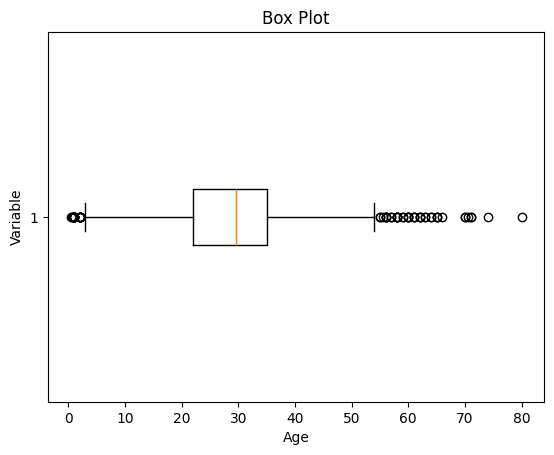

In [8]:
import matplotlib.pyplot as plt
plt.boxplot(df1['Age'], vert=False)
plt.ylabel('Variable')
plt.xlabel('Age')
plt.title('Box Plot')
plt.show()


Step 8: Calculate Outlier Boundaries and Remove Them

In [9]:
mean = df1['Age'].mean()
std = df1['Age'].std()
lower_bound = mean - 2 * std
upper_bound = mean + 2 * std
df2 = df1[(df1['Age'] >= lower_bound) & (df1['Age'] <= upper_bound)]


Step 9: Impute Missing Data Again if Any

In [10]:
df3 = df2.fillna(df2['Age'].mean())
df3.isnull().sum()


PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

Step 10: Recalculate Outlier Bounds and Remove Outliers from the Updated Data

In [11]:
mean = df3['Age'].mean()
std = df3['Age'].std()
lower_bound = mean - 2 * std
upper_bound = mean + 2 * std
print('Lower Bound :', lower_bound)
print('Upper Bound :', upper_bound)
df4 = df3[(df3['Age'] >= lower_bound) & (df3['Age'] <= upper_bound)]


Lower Bound : 8.978989004171453
Upper Bound : 49.30395961288914


Step 11: Data validation and verification

In [12]:
X = df3[['Pclass','Sex','Age', 'SibSp','Parch','Fare','Embarked']]
Y = df3['Survived']



Step 12: Data formatting

In [16]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Read dataset
df = pd.read_csv('Titanic-Dataset.csv')

# Create x
x = df

# Create scaler
scaler = MinMaxScaler(feature_range=(0,1))

# Select numeric columns
num_col_ = x.select_dtypes(include=['int64','float64']).columns

# Copy dataframe
x1 = x.copy()

# Fill missing values
x1[num_col_] = x1[num_col_].fillna(x1[num_col_].mean())

# Apply MinMax Scaling
x1[num_col_] = scaler.fit_transform(x1[num_col_])

# Display output
x1.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0.000000,0.0,1.0,"Braund, Mr. Owen Harris",male,0.271174,0.125,0.0,A/5 21171,0.014151,NaN,S
1,0.001124,1.0,0.0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,0.472229,0.125,0.0,PC 17599,0.139136,C85,C
2,0.002247,1.0,1.0,"Heikkinen, Miss. Laina",female,0.321438,0.000,0.0,STON/O2. 3101282,0.015469,NaN,S
3,0.003371,1.0,0.0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,0.434531,0.125,0.0,113803,0.103644,C123,S
4,0.004494,0.0,1.0,"Allen, Mr. William Henry",male,0.434531,0.000,0.0,373450,0.015713,NaN,S
